# Notebook exploring outliers using pyod

In [ ]:
import platform
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(os.getcwd())
system_name = platform.system()

pd.set_option("display.max_columns", None)

from helpers.dataframeBuilderPAQ import get_df_column_per_combination
from emmv import emmv_scores

from sklearn.preprocessing import MinMaxScaler

/home/miked/code/dep2-g2/anomalies/PAQ/scripts


In [2]:
LOTS_OF_TRAINING_TIME = False # Run all
RUN_OPTIONAL = False # Just skip a few

## LOF is proximity based

So anything that has to do with distances
In that aspect, I believe using the exented matrix is good

In [3]:
from pyod.models.copod import COPOD
from pyod.models.abod import ABOD
from pyod.models.lof import LOF
from pyod.models.iforest import IForest
# from pyod.models.ae1svm import AE1SVM
from pyod.models.knn import KNN
from pyod.models.iforest import IForest
from pyod.models.dif import DIF


In [4]:
df, df_test, _, _ = get_df_column_per_combination(join_candidate=True, min_max_scale=False)
df.index = df["TestKey"]
df.drop(columns="TestKey", inplace=True)
# Keep a 'copy' of candidate column, to join later again to check the results
df.drop(columns="CandidateKey", inplace=True)
df

,AHA_2EHA_4,AHA_4EHA_6,AHA_8BHA_8,AHZ_10EHA_2,AHZ_2AHA_10,AHZ_2EHA_2,AHZ_4DHA_2,AHZ_4DHA_4,AHZ_8CHA_10,APZ_6DZA_6,APZ_8DHA_8,AZA_10DHA_4,AZA_10DZA_2,AZA_4DZA_6,AZA_4EHA_4,BEW_1BEH_1,BEW_2BEH_2,BEW_3BEH_3,BEW_4BEH_4,BEW_5BEH_5,BEW_6BEH_6,BHA_10AHA_8,BHA_10EHA_10,BHZ_2CZA_10,BHZ_8DHA_10,BHZ_8DHA_6,BHZ_8DZA_6,BHZ_8EHA_10,BPZ_4CZA_10,BPZ_4DXZ_8,BPZ_6DZA_6,BPZ_8CZA_8,BPZ_8DZA_8,BXZ_4BZA_8,BXZ_4DZA_4,BXZ_8DHA_10,CHA_10AHA_4,CHA_10AHA_6,CHA_10EPZ_2,CPZ_8DZA_8,CXZ_10EHA_2,CZA_10EHA_4,CZA_8BZA_6,CZA_8DPZ_6,CZA_8DXZ_8,CZA_8DZA_4,CZA_8DZA_8,DEN_1DOE_1,DEN_2DOE_2,DEN_3DOE_3,DEN_4DOE_4,DEN_5DOE_5,DEN_6DOE_6,DHA_10BHA_2,DHA_10BHA_4,DHA_10EHZ_4,DHA_2CPZ_8,DHA_4EHA_4,DHZ_2BHA_10,DOB_1INB_1,DOB_2INB_2,DOB_3INB_3,DOB_4INB_4,DOB_5INB_5,DOB_6INB_6,DXZ_8AXZ_8,DXZ_8BPZ_8,DXZ_8CZA_2,DXZ_8CZA_6,DZA_10AHZ_6,DZA_10APZ_8,DZA_10EHA_4,DZA_10EPZ_2,DZA_4BPZ_8,DZA_4CPZ_8,DZA_4CXZ_4,DZA_4CZA_4,DZA_4DXZ_8,DZA_4DZA_8,DZA_6DZA_6,DZA_8CHA_4,DZA_8CXZ_4,DZA_8CZA_4,DZA_8DPZ_4,DZA_8DZA_4,EHA_10AHA_8,EHA_10AHZ_6,EHA_10BHA_2,EHA_2CPZ_6,EHA_4BHA_2,EHA_4EHA_10,EHA_8DHA_4,EXZ_2BHA_2,EXZ_4DZA_4,EZA_10AHZ_6,EZA_10EZA_4,EZA_2CZA_4,EZA_2DPZ_8,EZA_4EZA_10,EZA_6EXZ_10,EZA_6EZA_10,EZA_8DHA_4,FLE_1PLA_1,FLE_2PLA_2,FLE_3PLA_3,FLE_4PLA_4,FLE_5PLA_5,FLE_6PLA_6,INT_1EXT_1,INT_2EXT_2,INT_3EXT_3,INT_4EXT_4,INT_5EXT_5,INT_6EXT_6,OVE_1GED_1,OVE_2GED_2,OVE_3GED_3,OVE_4GED_4,OVE_5GED_5,OVE_6GED_6,PLI_1ZFS_1,PLI_2ZFS_2,PLI_3ZFS_3,PLI_4ZFS_4,PLI_5ZFS_5,PLI_6ZFS_6,REA_1OPT_1,REA_2OPT_2,REA_3OPT_3,REA_4OPT_4,REA_5OPT_5,REA_6OPT_6,REG_1AFW_1,REG_2AFW_2,REG_3AFW_3,REG_4AFW_4,REG_5AFW_5,REG_6AFW_6,RUS_1ENE_1,RUS_2ENE_2,RUS_3ENE_3,RUS_4ENE_4,RUS_5ENE_5,RUS_6ENE_6,SAL_1SBE_1,SAL_2SBE_2,SAL_3SBE_3,SAL_4SBE_4,SAL_5SBE_5,SAL_6SBE_6,STA_1AMB_1,STA_2AMB_2,STA_3AMB_3,STA_4AMB_4,STA_5AMB_5,STA_6AMB_6,VOL_1LEI_1,VOL_2LEI_2,VOL_3LEI_3,VOL_4LEI_4,VOL_5LEI_5,VOL_6LEI_6,ZEL_1SAM_1,ZEL_2SAM_2,ZEL_3SAM_3,ZEL_4SAM_4,ZEL_5SAM_5,ZEL_6SAM_6,ZIC_1AND_1,ZIC_2AND_2,ZIC_3AND_3,ZIC_4AND_4,ZIC_5AND_5,ZIC_6AND_6,DaysAgo,InstanceID_1,InstanceID_2,InstanceID_3,InstanceID_4,InstanceID_5,ChosenLanguage_63B7DCBF-919E-49A6-8BF4-7CD9042C4C44,ChosenLanguage_65CAFEA9-CF49-43ED-99AA-83AFE0539978,ChosenLanguage_BE3C46AE-0192-4A9B-ACEE-37E51836F77C,ChosenLanguage_C3389FD0-E729-4D22-8024-B8D6C76C380D,ChosenLanguage_FADAABC8-26DD-458B-B07E-BF96B4B3FCED,ChosenGender_Gender_Female,ChosenGender_Gender_Male,ChosenGender_Gender_Other,ChosenGender_Gender_Unknown,Gender_Gender_Female,Gender_Gender_Male,Gender_Gender_Unknown,Qualification_Qualification_Bachelor,Qualification_Qualification_MBA,Qualification_Qualification_Master,Qualification_Qualification_PHD,Qualification_Qualification_PostGraduate,Qualification_Qualification_Professional,Qualification_Qualification_Secondary,Qualification_Qualification_Unknown,Qualification_Qualification_Vocational
TestKey,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
166959,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,5.0,5.0,5.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,1.0,1.0,1.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,1.0,5.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,3.0,1.0,5.0,5.0,1.0,1.0,1.0,1.0,5.0,1.0,5.0,5.0,5.0,1.0,5.0,1.0,5.0,5.0,5.0,2.0,4.0,5.0,5.0,5.0,5.0,3.0,5.0,5.0,3.0,5.0,1.0,5.0,3.0,1.0,3.0,5.0,5.0,1.0,4.0,2.0,1.0,3.0,5.0,5.0,2.0,5.0,5.0,1.0,5.0,1.0,1.0,5.0,5.0,4.0,1.0,2.0,3.0,3.0,3.0,5.0,1.0,5.0,1.0,1.0,1.0,5.0,5.0,1.0,1.0,1.0,4.0,2153.0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0
166960,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,4.0,4.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,1.0,2.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,

In [5]:
outliers = {}
outliers["TestKey"] = df.index.to_list()

In [6]:
scaler = MinMaxScaler()

scaler.fit(df)

MinMaxScaler()

In [7]:
df = pd.DataFrame(scaler.transform(df), columns=df.columns)
df

,AHA_2EHA_4,AHA_4EHA_6,AHA_8BHA_8,AHZ_10EHA_2,AHZ_2AHA_10,AHZ_2EHA_2,AHZ_4DHA_2,AHZ_4DHA_4,AHZ_8CHA_10,APZ_6DZA_6,APZ_8DHA_8,AZA_10DHA_4,AZA_10DZA_2,AZA_4DZA_6,AZA_4EHA_4,BEW_1BEH_1,BEW_2BEH_2,BEW_3BEH_3,BEW_4BEH_4,BEW_5BEH_5,BEW_6BEH_6,BHA_10AHA_8,BHA_10EHA_10,BHZ_2CZA_10,BHZ_8DHA_10,BHZ_8DHA_6,BHZ_8DZA_6,BHZ_8EHA_10,BPZ_4CZA_10,BPZ_4DXZ_8,BPZ_6DZA_6,BPZ_8CZA_8,BPZ_8DZA_8,BXZ_4BZA_8,BXZ_4DZA_4,BXZ_8DHA_10,CHA_10AHA_4,CHA_10AHA_6,CHA_10EPZ_2,CPZ_8DZA_8,CXZ_10EHA_2,CZA_10EHA_4,CZA_8BZA_6,CZA_8DPZ_6,CZA_8DXZ_8,CZA_8DZA_4,CZA_8DZA_8,DEN_1DOE_1,DEN_2DOE_2,DEN_3DOE_3,DEN_4DOE_4,DEN_5DOE_5,DEN_6DOE_6,DHA_10BHA_2,DHA_10BHA_4,DHA_10EHZ_4,DHA_2CPZ_8,DHA_4EHA_4,DHZ_2BHA_10,DOB_1INB_1,DOB_2INB_2,DOB_3INB_3,DOB_4INB_4,DOB_5INB_5,DOB_6INB_6,DXZ_8AXZ_8,DXZ_8BPZ_8,DXZ_8CZA_2,DXZ_8CZA_6,DZA_10AHZ_6,DZA_10APZ_8,DZA_10EHA_4,DZA_10EPZ_2,DZA_4BPZ_8,DZA_4CPZ_8,DZA_4CXZ_4,DZA_4CZA_4,DZA_4DXZ_8,DZA_4DZA_8,DZA_6DZA_6,DZA_8CHA_4,DZA_8CXZ_4,DZA_8CZA_4,DZA_8DPZ_4,DZA_8DZA_4,EHA_10AHA_8,EHA_10AHZ_6,EHA_10BHA_2,EHA_2CPZ_6,EHA_4BHA_2,EHA_4EHA_10,EHA_8DHA_4,EXZ_2BHA_2,EXZ_4DZA_4,EZA_10AHZ_6,EZA_10EZA_4,EZA_2CZA_4,EZA_2DPZ_8,EZA_4EZA_10,EZA_6EXZ_10,EZA_6EZA_10,EZA_8DHA_4,FLE_1PLA_1,FLE_2PLA_2,FLE_3PLA_3,FLE_4PLA_4,FLE_5PLA_5,FLE_6PLA_6,INT_1EXT_1,INT_2EXT_2,INT_3EXT_3,INT_4EXT_4,INT_5EXT_5,INT_6EXT_6,OVE_1GED_1,OVE_2GED_2,OVE_3GED_3,OVE_4GED_4,OVE_5GED_5,OVE_6GED_6,PLI_1ZFS_1,PLI_2ZFS_2,PLI_3ZFS_3,PLI_4ZFS_4,PLI_5ZFS_5,PLI_6ZFS_6,REA_1OPT_1,REA_2OPT_2,REA_3OPT_3,REA_4OPT_4,REA_5OPT_5,REA_6OPT_6,REG_1AFW_1,REG_2AFW_2,REG_3AFW_3,REG_4AFW_4,REG_5AFW_5,REG_6AFW_6,RUS_1ENE_1,RUS_2ENE_2,RUS_3ENE_3,RUS_4ENE_4,RUS_5ENE_5,RUS_6ENE_6,SAL_1SBE_1,SAL_2SBE_2,SAL_3SBE_3,SAL_4SBE_4,SAL_5SBE_5,SAL_6SBE_6,STA_1AMB_1,STA_2AMB_2,STA_3AMB_3,STA_4AMB_4,STA_5AMB_5,STA_6AMB_6,VOL_1LEI_1,VOL_2LEI_2,VOL_3LEI_3,VOL_4LEI_4,VOL_5LEI_5,VOL_6LEI_6,ZEL_1SAM_1,ZEL_2SAM_2,ZEL_3SAM_3,ZEL_4SAM_4,ZEL_5SAM_5,ZEL_6SAM_6,ZIC_1AND_1,ZIC_2AND_2,ZIC_3AND_3,ZIC_4AND_4,ZIC_5AND_5,ZIC_6AND_6,DaysAgo,InstanceID_1,InstanceID_2,InstanceID_3,InstanceID_4,InstanceID_5,ChosenLanguage_63B7DCBF-919E-49A6-8BF4-7CD9042C4C44,ChosenLanguage_65CAFEA9-CF49-43ED-99AA-83AFE0539978,ChosenLanguage_BE3C46AE-0192-4A9B-ACEE-37E51836F77C,ChosenLanguage_C3389FD0-E729-4D22-8024-B8D6C76C380D,ChosenLanguage_FADAABC8-26DD-458B-B07E-BF96B4B3FCED,ChosenGender_Gender_Female,ChosenGender_Gender_Male,ChosenGender_Gender_Other,ChosenGender_Gender_Unknown,Gender_Gender_Female,Gender_Gender_Male,Gender_Gender_Unknown,Qualification_Qualification_Bachelor,Qualification_Qualification_MBA,Qualification_Qualification_Master,Qualification_Qualification_PHD,Qualification_Qualification_PostGraduate,Qualification_Qualification_Professional,Qualification_Qualification_Secondary,Qualification_Qualification_Unknown,Qualification_Qualification_Vocational
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,1.0,1.0,1.0,1.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.2,0.2,0.2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0.4,0.2,1.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.6,0.2,1.0,1.0,0.2,0.2,0.2,0.2,1.0,0.2,1.0,1.0,1.0,0.2,1.0,0.2,1.0,1.0,1.0,0.4,0.8,1.0,1.0,1.0,1.0,0.6,1.0,1.0,0.6,1.0,0.2,1.0,0.6,0.2,0.6,1.0,1.0,0.2,0.8,0.4,0.2,0.6,1.0,1.0,0.4,1.0,1.0,0.2,1.0,0.2,0.2,1.0,1.0,0.8,0.2,0.4,0.6,0.6,0.6,1.0,0.2,1.0,0.2,0.2,0.2,1.0,1.0,0.2,0.2,0.2,0.8,0.982263,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.4,0.8,0.8,0.6,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.4,0.2,0.4,0.6,0.6,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.4,0.8,0.2,0.4,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

## Local Outlier Factor

In [8]:
model = LOF(contamination=0.05)

model.fit(df)

# Predict the outliers (1 means outlier, 0 means inlier)
outliers["lof"] =  model.predict(df)
outliers["lof"]

array([1, 0, 0, ..., 0, 0, 0])

In [9]:
# Add the outlier prediction to the DataFrame
# emmv_lof = emmv_scores(lof, df, n_generated=len(df))
# emmv_lof

In [10]:
if LOTS_OF_TRAINING_TIME:
    model = LOF(metric='manhattan', contamination=0.05)
    model.fit(df)
    outliers["lof_manhattan"] = model.predict(df)
    outliers["lof_manhattan"]

In [11]:
# lof_outliers2

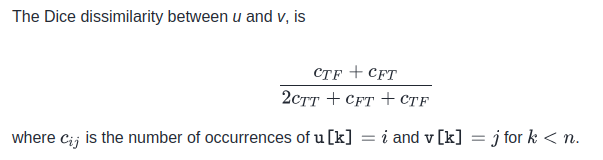
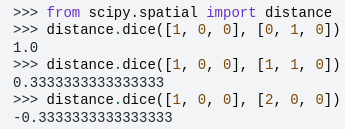
I don't get the distance, but it seems different

In [12]:
if LOTS_OF_TRAINING_TIME:
    model = LOF(metric='dice', contamination=0.05)
    model.fit(df)
    outliers["lof_dice"] = model.predict(df)

In [13]:
# outliers = np.ndarray([lof_outliers, lof_outliers2, lof_outliers3])
# outliers

# Hamming

The Hamming distance between 1-D arrays u and v, is simply the proportion of disagreeing components in u and v. 

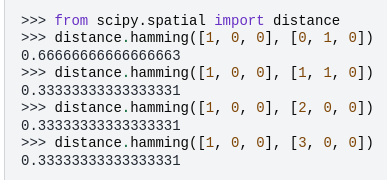

In [14]:
if RUN_OPTIONAL or LOTS_OF_TRAINING_TIME:
    model = LOF(metric='hamming', contamination=0.05)
    model.fit(df)
    outliers["lof_hamming"] = model.predict(df)

## Linear or PCA based

Principal component analysis (PCA) can be used in detecting outliers. PCA is a linear dimensionality reduction using Singular Value Decomposition of the data to project it to a lower dimensional space.

In this procedure, covariance matrix of the data can be decomposed to orthogonal vectors, called eigenvectors, associated with eigenvalues. The eigenvectors with high eigenvalues capture most of the variance in the data.

Therefore, a low dimensional hyperplane constructed by k eigenvectors can capture most of the variance in the data. However, outliers are different from normal data points, which is more obvious on the hyperplane constructed by the eigenvectors with small eigenvalues.

Therefore, outlier scores can be obtained as the sum of the projected distance of a sample on all eigenvectors.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Example: Load a dataset (replace with your own dataset)
X = df

# Standardize the data (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 1: Fit PCA
pca = PCA()
pca.fit(X_scaled)

PCA()

In [16]:
# Step 2: Calculate cumulative variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
cumulative_variance



array([0.09663104, 0.18750211, 0.27236292, 0.34890453, 0.42421583,
       0.46439134, 0.4976244 , 0.52493923, 0.54581216, 0.56349229,
       0.5784359 , 0.59221676, 0.60443053, 0.61466285, 0.62469692,
       0.63400935, 0.64287789, 0.65157531, 0.66021874, 0.6682106 ,
       0.67552215, 0.68247143, 0.68891954, 0.69506097, 0.70092612,
       0.70669947, 0.71228425, 0.7177772 , 0.72317756, 0.72844975,
       0.73362823, 0.73877151, 0.74383091, 0.74887889, 0.75388047,
       0.75883812, 0.7637553 , 0.76862413, 0.7734612 , 0.77812706,
       0.78268996, 0.78718405, 0.79154277, 0.79579909, 0.80001158,
       0.80416026, 0.80826085, 0.81232258, 0.8163515 , 0.82026653,
       0.82412162, 0.82795539, 0.83169061, 0.83541671, 0.83910885,
       0.84277009, 0.84635255, 0.8498933 , 0.85339861, 0.85686261,
       0.86030903, 0.8637313 , 0.86712579, 0.87046606, 0.8737989 ,
       0.87707387, 0.88029643, 0.88351646, 0.88668581, 0.88982677,
       0.89295051, 0.89606167, 0.89913164, 0.90218783, 0.90522

In [17]:
explained_variance_ratio

array([9.66310356e-02, 9.08710750e-02, 8.48608075e-02, 7.65416086e-02,
       7.53113053e-02, 4.01755123e-02, 3.32330576e-02, 2.73148322e-02,
       2.08729237e-02, 1.76801324e-02, 1.49436110e-02, 1.37808563e-02,
       1.22137724e-02, 1.02323195e-02, 1.00340701e-02, 9.31242755e-03,
       8.86853942e-03, 8.69742280e-03, 8.64343541e-03, 7.99185683e-03,
       7.31155208e-03, 6.94927199e-03, 6.44811716e-03, 6.14142323e-03,
       5.86514963e-03, 5.77335205e-03, 5.58478675e-03, 5.49295060e-03,
       5.40035611e-03, 5.27219355e-03, 5.17847636e-03, 5.14328378e-03,
       5.05939807e-03, 5.04797972e-03, 5.00157776e-03, 4.95765411e-03,
       4.91717150e-03, 4.86883607e-03, 4.83706470e-03, 4.66586061e-03,
       4.56290074e-03, 4.49409267e-03, 4.35871923e-03, 4.25631778e-03,
       4.21249373e-03, 4.14867656e-03, 4.10059509e-03, 4.06172267e-03,
       4.02892230e-03, 3.91503470e-03, 3.85508771e-03, 3.83376818e-03,
       3.73521893e-03, 3.72609870e-03, 3.69214359e-03, 3.66123511e-03,
      

In [18]:
# Step 3: Find number of components that explain 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1  # Add 1 since index starts from 0

print(f"Number of components to explain 95% variance: {n_components_95}")
print("Explained variance ratio for each component:")
for i, var in enumerate(explained_variance_ratio, 1):
    print(f"PC-{i}: {var:.4f}")


Number of components to explain 95% variance: 91
Explained variance ratio for each component:
PC-1: 0.0966
PC-2: 0.0909
PC-3: 0.0849
PC-4: 0.0765
PC-5: 0.0753
PC-6: 0.0402
PC-7: 0.0332
PC-8: 0.0273
PC-9: 0.0209
PC-10: 0.0177
PC-11: 0.0149
PC-12: 0.0138
PC-13: 0.0122
PC-14: 0.0102
PC-15: 0.0100
PC-16: 0.0093
PC-17: 0.0089
PC-18: 0.0087
PC-19: 0.0086
PC-20: 0.0080
PC-21: 0.0073
PC-22: 0.0069
PC-23: 0.0064
PC-24: 0.0061
PC-25: 0.0059
PC-26: 0.0058
PC-27: 0.0056
PC-28: 0.0055
PC-29: 0.0054
PC-30: 0.0053
PC-31: 0.0052
PC-32: 0.0051
PC-33: 0.0051
PC-34: 0.0050
PC-35: 0.0050
PC-36: 0.0050
PC-37: 0.0049
PC-38: 0.0049
PC-39: 0.0048
PC-40: 0.0047
PC-41: 0.0046
PC-42: 0.0045
PC-43: 0.0044
PC-44: 0.0043
PC-45: 0.0042
PC-46: 0.0041
PC-47: 0.0041
PC-48: 0.0041
PC-49: 0.0040
PC-50: 0.0039
PC-51: 0.0039
PC-52: 0.0038
PC-53: 0.0037
PC-54: 0.0037
PC-55: 0.0037
PC-56: 0.0037
PC-57: 0.0036
PC-58: 0.0035
PC-59: 0.0035
PC-60: 0.0035
PC-61: 0.0034
PC-62: 0.0034
PC-63: 0.0034
PC-64: 0.0033
PC-65: 0.0033
PC-66

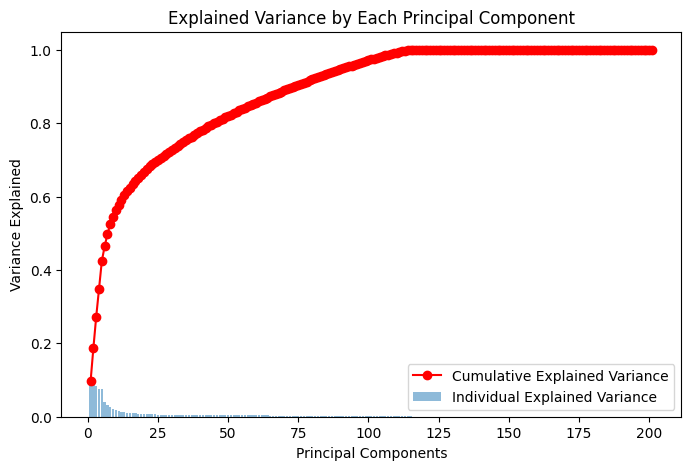

In [19]:

# Step 4: Plot explained variance for each component
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.5, label="Individual Explained Variance")
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='r', label="Cumulative Explained Variance")
plt.xlabel('Principal Components')
plt.ylabel('Variance Explained')
plt.title('Explained Variance by Each Principal Component')
plt.legend()
plt.show()



In [20]:
# Step 5: Use only the first `n_components_95` components
pca_95 = PCA(n_components=n_components_95)
X_pca_95 = pca_95.fit_transform(X_scaled)



In [21]:
# n_components_95

In [22]:
from pyod.models.pca import PCA as pyodPCA

In [23]:
model = pyodPCA(n_components=0.95, svd_solver="full", contamination=0.05)
model.fit(df)
outliers["pca"] = model.predict(df)
outliers["pca"]

array([1, 0, 0, ..., 0, 0, 1])

In [24]:
# copod = COPOD(contamination=0.05)
# copod.fit(df)

In [25]:
# outliers["copod"] = copod.predict(df)

In [26]:
# minimum 44 min
if LOTS_OF_TRAINING_TIME:
    model = KNN(contamination=0.05)
    model.fit(df)
    outliers["knn"] = model.predict(df)
    outliers["knn"]

In [27]:
if RUN_OPTIONAL or LOTS_OF_TRAINING_TIME:
    model = KNN(contamination=0.05, method='average')
    model.fit(df)
    outliers["knn_average"] = model.predict(df)
    outliers["knn_average"]

In [28]:
if LOTS_OF_TRAINING_TIME:
    model = KNN(contamination=0.05, n_neighbors=8)
    model.fit(df)
    outliers["knn_largest_8"] = model.predict(df)
    outliers["knn_largest_8"]

In [29]:
model = IForest(contamination=0.05)
model.fit(df)
outliers["iforest"] = model.predict(df)
outliers["iforest"]

/home/miked/code/dep2-g2/venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


array([1, 0, 0, ..., 0, 0, 1])

In [30]:
model = DIF(contamination=0.05)
model.fit(df)
outliers["deep_iforest"] = model.predict(df)
outliers["deep_iforest"]

array([0, 0, 0, ..., 0, 0, 0])

## Wanna try-out
 
- ABOD (Angle based outlier detection) or FastABOD
- COPOD
- KNN
- IForest


In [31]:
outliers

{'TestKey': [166959,
  166960,
  166961,
  166962,
  166963,
  166964,
  166965,
  166966,
  166967,
  166968,
  166969,
  166970,
  166971,
  166972,
  166973,
  166974,
  166975,
  166976,
  166977,
  166978,
  166979,
  166980,
  166981,
  166982,
  166983,
  166984,
  166985,
  166986,
  166987,
  166988,
  166989,
  166990,
  166991,
  166992,
  166993,
  166994,
  166995,
  166996,
  166997,
  166998,
  166999,
  167000,
  167001,
  167002,
  167003,
  167004,
  167005,
  167006,
  167007,
  167008,
  167009,
  167010,
  167011,
  167012,
  167013,
  167014,
  167015,
  167016,
  167017,
  167018,
  167019,
  167020,
  167021,
  167022,
  167023,
  167024,
  167025,
  167026,
  167027,
  167028,
  167029,
  167030,
  167031,
  167032,
  167033,
  167034,
  167035,
  167036,
  167037,
  167038,
  167039,
  167040,
  167041,
  167042,
  167043,
  167044,
  167045,
  167046,
  167047,
  167048,
  167049,
  167050,
  167051,
  167052,
  167053,
  167054,
  167055,
  167056,
  167057,

In [32]:
df_outliers = pd.DataFrame(outliers)
columns = df_outliers.columns.to_list()
columns.remove("TestKey")
df_outliers['count'] =  df_outliers[columns].sum(axis=1)
df_outliers['pyod % outlier'] = df_outliers['count'] / len(columns)
df_outliers

,TestKey,lof,pca,iforest,deep_iforest,count,pyod % outlier
0,166959,1,1,1,0,3,0.75
1,166960,0,0,0,0,0,0.00
2,166961,0,0,0,0,0,0.00
3,166962,0,1,1,0,2,0.50
4,166963,0,0,0,0,0,0.00
...,...,...,...,...,...,...,...
16675,183634,0,0,0,0,0,0.00
16676,183635,0,0,0,0,0,0.00
16677,183636,0,0,0,0,0,0.00
16678,183637,0,0,0,0,0,0.00


In [33]:
df_outliers['count'].value_counts()

count
0    15041
1      814
2      312
3      297
4      216
Name: count, dtype: int64

In [34]:
TRESHOLD = 0.5
df_outliers["is_anomaly"] = np.where(df_outliers['pyod % outlier'] >= TRESHOLD, 1, 0)
df_outliers

,TestKey,lof,pca,iforest,deep_iforest,count,pyod % outlier,is_anomaly
0,166959,1,1,1,0,3,0.75,1
1,166960,0,0,0,0,0,0.00,0
2,166961,0,0,0,0,0,0.00,0
3,166962,0,1,1,0,2,0.50,1
4,166963,0,0,0,0,0,0.00,0
...,...,...,...,...,...,...,...,...
16675,183634,0,0,0,0,0,0.00,0
16676,183635,0,0,0,0,0,0.00,0
16677,183636,0,0,0,0,0,0.00,0
16678,183637,0,0,0,0,0,0.00,0


In [35]:
df_outliers.to_csv("../csv/pyod_ensemble.csv", index=False)